**In this notebook, I used a hunch to include the 'id' column in the train, test, and original datasets. All I can say is WOW! what a difference it made in the CV score.**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/diabetes-health-indicators-dataset/diabetes_dataset.csv
/kaggle/input/playground-series-s5e12/sample_submission.csv
/kaggle/input/playground-series-s5e12/train.csv
/kaggle/input/playground-series-s5e12/test.csv


In [2]:
# import the necessary libraries

import seaborn as sns
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier

from sklearn.metrics import roc_auc_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

In [3]:
# get the data
train = pd.read_csv('/kaggle/input/playground-series-s5e12/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s5e12/test.csv')
orig = pd.read_csv('/kaggle/input/diabetes-health-indicators-dataset/diabetes_dataset.csv')
sample = pd.read_csv('/kaggle/input/playground-series-s5e12/sample_submission.csv')

#train = train.drop(columns=['id'])
#test = test.drop(columns=['id'])

In [4]:
# add 'id' column in the original dataset
orig['id'] = orig.index

In [5]:
# ensure original dataset has the same columns as the training dataset
orig = orig[train.columns.to_list()]

In [6]:
print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')
print(f'Orig shape: {orig.shape}')

Train shape: (700000, 26)
Test shape: (300000, 25)
Orig shape: (100000, 26)


In [7]:
train = train.merge(orig, how='outer')
train.shape

(800000, 26)

In [8]:
class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups
                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

In [9]:
# bmi score categories
def bmi_classification(score):
  if score >= 30:
    return 'Obese'
  elif score >= 25:
    return 'Overwieght'
  elif score >= 18.5:
    return 'Normal'
  else:
    return 'Underweight'

for d in [train, test, orig]:
  d['bmi_category'] = d['bmi'].apply(bmi_classification)

In [10]:
new_features = []
features = test.columns.to_list()
for col in features:
    # Mean
    tmp = orig.groupby(col)['diagnosed_diabetes'].mean()
    new_name = 'orig_' + str(col)
    tmp.name = new_name
    train = train.merge(tmp, how='left', on=col)
    test = test.merge(tmp, how='left', on=col)
    new_features.append(new_name)

    # Count
    tmp_cnt_name = 'orig_cnt_' + str(col)
    tmp_cnt = orig.groupby(col).size().reset_index(name=tmp_cnt_name)
    train = train.merge(tmp_cnt, how='left', on=col)
    test = test.merge(tmp_cnt, how='left', on=col)
    new_features.append(tmp_cnt_name)


new_base = features + new_features
print(f'New features: {len(new_base)}')

New features: 78


In [11]:
# look at the categorical columns for their unique values
objs = train.select_dtypes(include='object').columns.to_list()
for obj in objs:
    print(obj)
    print(train[obj].unique())

gender
['Female' 'Male' 'Other']
ethnicity
['Hispanic' 'Asian' 'White' 'Black' 'Other']
education_level
['Highschool' 'Graduate' 'Postgraduate' 'No formal']
income_level
['Lower-Middle' 'Middle' 'Upper-Middle' 'Low' 'High']
smoking_status
['Current' 'Never' 'Former']
employment_status
['Employed' 'Retired' 'Unemployed' 'Student']
bmi_category
['Obese' 'Normal' 'Overwieght' 'Underweight']


In [12]:
# convert the object datatype columns into category dtypes
objs = train.select_dtypes(include='object').columns.to_list()
for obj in objs:
    train[obj] = train[obj].astype('category')
    test[obj] = test[obj].astype('category')

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800000 entries, 0 to 799999
Data columns (total 79 columns):
 #   Column                                       Non-Null Count   Dtype   
---  ------                                       --------------   -----   
 0   id                                           800000 non-null  int64   
 1   age                                          800000 non-null  int64   
 2   alcohol_consumption_per_week                 800000 non-null  int64   
 3   physical_activity_minutes_per_week           800000 non-null  int64   
 4   diet_score                                   800000 non-null  float64 
 5   sleep_hours_per_day                          800000 non-null  float64 
 6   screen_time_hours_per_day                    800000 non-null  float64 
 7   bmi                                          800000 non-null  float64 
 8   waist_to_hip_ratio                           800000 non-null  float64 
 9   systolic_bp                                  800

In [13]:
# label encoding really helped the score improve
# focus only on the object columns for labe encoding
objects = train.select_dtypes('category').columns

for obj in objects:
    le = LabelEncoder()
    le.fit(pd.concat([train[obj],test[obj]], axis=0).astype(str))
    train[obj] = le.transform(train[obj].astype(str))
    test[obj] = le.transform(test[obj].astype(str))

In [14]:
CAT_params = {
        'n_estimators':12000,
        'depth':3,
        'learning_rate':0.01,
        'eval_metric': 'AUC',
        'random_seed':123,
        'use_best_model':True,
        'verbose':0,
        'early_stopping_rounds':300,
        'task_type':'GPU'
}

In [15]:
X = train.drop(columns=['diagnosed_diabetes'])
y = train['diagnosed_diabetes']

In [16]:
int_cols = X.select_dtypes(include=['int','float']).columns.to_list()

folds = 5
skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

cat_test_pred = np.zeros(len(test))

cat_auc_scores = []

In [17]:
for i, (train_index, test_index) in enumerate(skf.split(X, y),1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    TE = TargetEncoder(cols_to_encode=int_cols, cv=5, smooth='auto',aggs=['mean'], drop_original=False)
    X_train = TE.fit_transform(X_train, y_train)
    X_test = TE.transform(X_test)
    test = TE.transform(test)

    # CatBoostClassifier
    cat_model = CatBoostClassifier(**CAT_params)
    cat_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    cat_test_pred += cat_model.predict_proba(test)[:,1]/folds
    cat_y_pred = cat_model.predict_proba(X_test)[:,1]
    cat_auc_score = roc_auc_score(y_test, cat_y_pred)
    cat_auc_scores.append(cat_auc_score)
    print(f'Fold {i} CatBoost AUC score: {cat_auc_score:.5f}')

Default metric period is 5 because AUC is/are not implemented for GPU


Fold 1 CatBoost AUC score: 0.78201


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 2 CatBoost AUC score: 0.78155


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 3 CatBoost AUC score: 0.78011


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 4 CatBoost AUC score: 0.78144


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 5 CatBoost AUC score: 0.78267


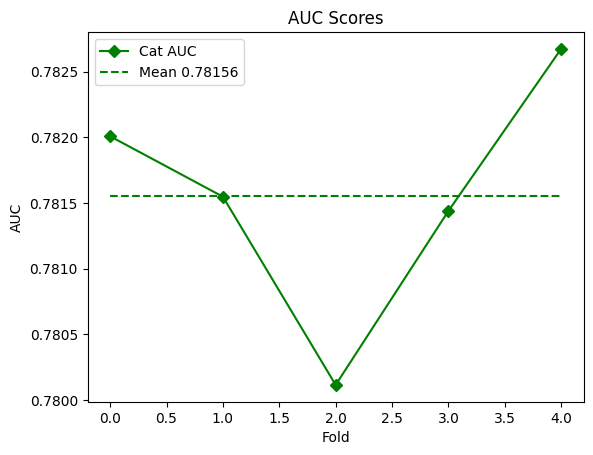

In [18]:
plt.plot(cat_auc_scores, label='Cat AUC', marker='D', linestyle='-', color='green')
plt.hlines(y=np.mean(cat_auc_scores), xmin=0, xmax=folds-1, linestyles='--',
           colors='green', label='Mean ' + str(np.round(np.mean(cat_auc_scores),5)))
plt.xlabel('Fold')
plt.ylabel('AUC')
plt.title('AUC Scores')
plt.legend()
plt.show()

In [19]:
# package the predictions for submission
submission = pd.DataFrame({
    'id': sample['id'],
    'diagnosed_diabetes': cat_test_pred
})
submission.to_csv('submission.csv', index=False)
submission[:5]

,id,diagnosed_diabetes
0,700000,0.486911
1,700001,0.697775
2,700002,0.780349
3,700003,0.425970
4,700004,0.910173
